In [1]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# low_pass_filter_Data
def low_pass_filter(sig, fs, f_cut, order):
    """
    applies zero-lag butterworth filter to a DataFrame
    :param sig: signal to be filtered - DataFrame
    :param fs: sampling frequency of sig - integer
    :param f_cut: cut-off frequency (low-pass) - integer
    :param order: order of filter - integer
    :return sig_filt: filtered signal - DataFrame
    """
    # design filter
    nf = f_cut/(fs/2)
    b, a = butter(order, nf, btype='low')
    
    sig_filt=pd.DataFrame(columns = sig.columns)
    
    for col in sig.columns:
        sig_filt[col] = filtfilt(b, a, sig[col], padtype='odd', padlen=3*(max(len(b), len(a))-1))
    return sig_filt

In [3]:
def segment_steps(force_df, fs):
    f_vert = pd.DataFrame(-force_df["Fz"])
     # get highly smoothed signal for peak detection
    highly_smoothed_sig = low_pass_filter(f_vert, fs, 5, 4)

    # grab all smooth peaks above 500 Newtons
    peaks, _ = find_peaks(highly_smoothed_sig.squeeze(), height=500)
    # remove first and last peaks to avoid partial GRFs
    # peaks = np.delete(peaks, [0, -1])

    # squeeze to np array for further processing
    slightly_smoothed_sig = f_vert.values.squeeze()

    # extract HS (search from peak to the left while GRF > 20)
    HS_list = []
    # extract TO (search from peak to the right while GRF > 20)
    TO_list = []

    for peak in peaks:
        peak_hs_copy = peak
        while (peak_hs_copy > 0) & (slightly_smoothed_sig[peak_hs_copy] > 20):
            peak_hs_copy = peak_hs_copy - 1
        HS_list.append(peak_hs_copy + 1)  # go one back

        peak_to_copy = peak
        while (peak_to_copy < len(slightly_smoothed_sig)) & (slightly_smoothed_sig[peak_to_copy] > 20):
            peak_to_copy = peak_to_copy + 1
        TO_list.append(peak_to_copy - 1)  # go on back

    HS_list = list(set(HS_list))  # removes possible duplicates
    HS_list.sort()

    TO_list = list(set(TO_list))  # removes possible duplicates
    TO_list.sort()

    # make sure to start with HS and end with TO
    if HS_list[0] > TO_list[0]:
        HS_list = HS_list[:-1]
        TO_list = TO_list[1:]
    elif HS_list[-1] > TO_list[-1]:
        HS_list = HS_list[:-1]
        TO_list = TO_list[1:]
    try:
        len(TO_list) == len(HS_list)
    except:
        print("different number of HS and TO detected, something is wrong here..")
    
    IC = np.array(HS_list)
    TO = np.array(TO_list)
    return IC, TO

In [4]:
def ic_benson(df_in, fs):
    racc = np.linalg.norm(df_in.iloc[:,:3],axis=1)
    ic, _ = find_peaks(racc, distance = fs//2, height = np.mean(racc))
    return ic[:-1]

In [5]:
def to_benson(df_in, ic, fs):
    to = np.empty(ic.shape)
    vacc = -df_in.iloc[:,2]
    for i in range(len(ic)):
        w1 = ic[i]+fs//10
        #print('w1: ', w1)
        if i != len(ic)-1:
            w2 = (ic[i] + ic[i+1])//2
            #print('w2: ', w2)
        else:
            w2 = df.index[-1]
            #print('last w2: ', w2)
        peaks, _ = find_peaks(vacc[w1:w2])
        if len(peaks)<1:
            to[i] = vacc[w1:w2].idxmax()
        else:
            to[i] = vacc[peaks+w1].idxmax()
    return to.astype(int)

In [6]:
# import data
df = pd.read_csv('D:\\Salzburg\\TexSense\\Messungen\\PI_FP_IMU\\RUN_03.csv', sep = ',', header = [3], low_memory = False)
ff = df.iloc[df[df['Frame']=='Frame'].index[0]+2:, :]
ff.columns = df.iloc[df[df['Frame']=='Frame'].index[0],:].values.tolist()
force_df = ff[['Fx','Fy','Fz','Mx','My','Mz','Cx','Cy','Cz']].astype('float').reset_index()
imu_df = df.iloc[1:df[df['Frame']=='Devices'].index[0], :].astype('float')[::2]

In [7]:
left = imu_df[imu_df.columns[imu_df.columns.str.contains(pat = 'IMU1_')]].reset_index().iloc[:,1:]
right = imu_df[imu_df.columns[imu_df.columns.str.contains(pat = 'IMU2_')]].reset_index().iloc[:,1:]

In [8]:
# get real IC and TO
ic_true, to_true = segment_steps(force_df, 1000)
print('number of steps :', len(ic_true))

number of steps : 156


In [58]:
# Benson 2019
# x = running direction
# y = transversal/ML axis (left)
# z = vertical direction
b_left = pd.DataFrame(low_pass_filter(left, 2000, 10, 4), columns = left.columns)
b_right = pd.DataFrame(low_pass_filter(right, 2000, 10, 4), columns = right.columns)

### Filtered Signal

(0.0, 160000.0)

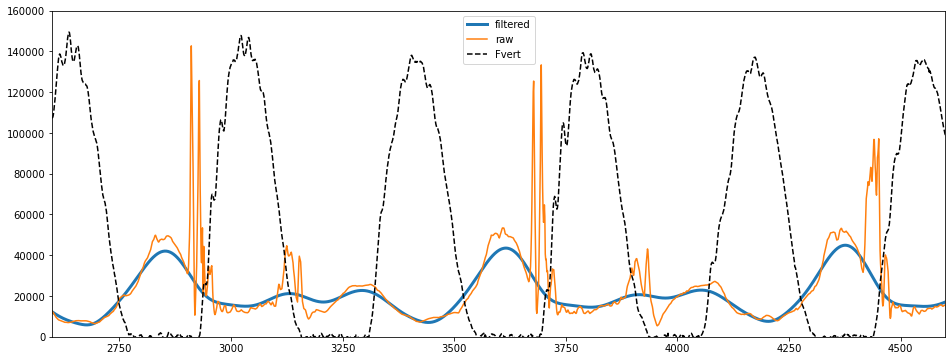

In [60]:
fig = plt.figure(figsize = (16,6))
plt.plot(np.linalg.norm(b_left.iloc[:,:3], axis=1), label = 'filtered', linewidth = 3)
plt.plot(np.linalg.norm(left.iloc[:,:3], axis=1), label = 'raw')
plt.plot(-force_df['Fz']*80, 'k--', label = 'Fvert')
plt.legend()
plt.xlim(2600,4600)
plt.ylim(0,160000)

In [11]:
ic_bl = ic_benson(b_left,1000)
to_bl = to_benson(b_left, ic_bl, 1000)
ic_br = ic_benson(b_right,1000)
to_br = to_benson(b_right, ic_br, 1000)

In [52]:
#ic_bl

In [53]:
#ic_br

### Toe off

(-2300.0, 2300.0)

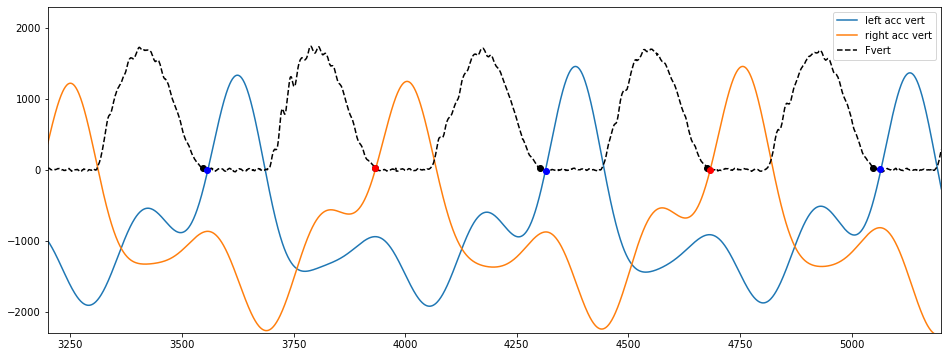

In [56]:
fig = plt.figure(figsize = (16,6))
#plt.plot(np.linalg.norm(b_left.iloc[:,:3],axis=1)/25)
#plt.plot(np.linalg.norm(b_right.iloc[:,:3],axis=1)/25)
#plt.plot(ic_b, np.linalg.norm(b_left.iloc[:,:3],axis=1)[ic_b], 'X')
#plt.plot(to_b, (-b_left['IMU1_ACC_Z'])[to_b], 'o')
plt.plot(-b_left['IMU1_ACC_Z']/10, label='left acc vert')
plt.plot(-b_right['IMU2_ACC_Z']/10, label='right acc vert')
plt.plot(-force_df['Fz'], 'k--', label = 'Fvert')
plt.plot(to_true, (-force_df['Fz'])[to_true], 'o', c = 'k')
#plt.plot(ic_true, (-force_df['Fz'])[ic_true], 'X', c = 'g')

plt.plot(to_bl, (-force_df['Fz'])[to_bl], 'o', c = 'r')
#plt.plot(ic_bl, (-force_df['Fz'])[ic_bl], 'X', c = 'r')
plt.plot(to_br, (-force_df['Fz'])[to_br], 'o', c = 'b')
#plt.plot(ic_br, (-force_df['Fz'])[ic_br], 'X', c = 'r')
plt.legend()
#plt.plot(-b_left['IMU1_ACC_Z'])
plt.xlim(3200,5200)
plt.ylim(-2300,2300)

### Initial Contact

(3200.0, 5200.0)

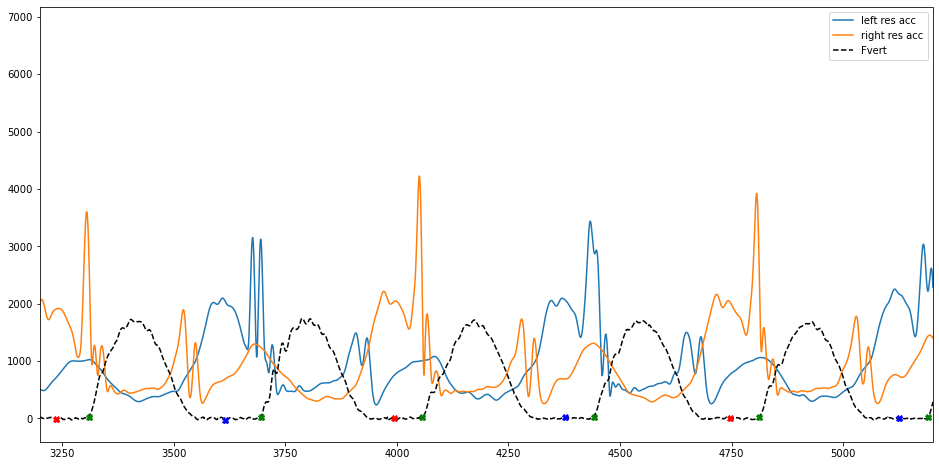

In [38]:
fig = plt.figure(figsize = (16,8))
plt.plot(np.linalg.norm(b_left.iloc[:,:3],axis=1)/25, label='left res acc')
plt.plot(np.linalg.norm(b_right.iloc[:,:3],axis=1)/25, label='right res acc')
#plt.plot(ic_b, np.linalg.norm(b_left.iloc[:,:3],axis=1)[ic_b], 'X')
#plt.plot(to_b, (-b_left['IMU1_ACC_Z'])[to_b], 'o')
plt.plot(-force_df['Fz'], 'k--', label = 'Fvert')
#plt.plot(to_true, (-force_df['Fz'])[to_true], 'o', c = 'k')
plt.plot(ic_true, (-force_df['Fz'])[ic_true], 'X', c = 'g')

#plt.plot(to_bl, (-force_df['Fz'])[to_bl], 'o', c = 'r')
plt.plot(ic_bl, (-force_df['Fz'])[ic_bl], 'X', c = 'b')
#plt.plot(to_br, (-force_df['Fz'])[to_br], 'o', c = 'b')
plt.plot(ic_br, (-force_df['Fz'])[ic_br], 'X', c = 'r')
plt.legend()
#plt.plot(-b_left['IMU1_ACC_Z'])
plt.xlim(3200,5200)

In [16]:
ic_l = ic_true[2::2]
to_l = to_true[2::2]
ic_r = ic_true[1::2][:-1]
to_r = to_true[1::2][:-1]

In [17]:
#to_true[1::2][:-1]

In [18]:
#to_br

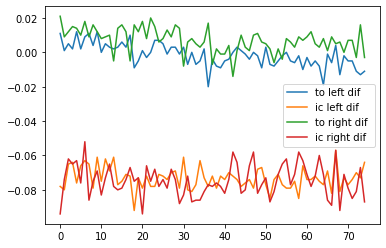

In [19]:
plt.plot((to_bl[1:-1] - to_l[1:-1])/1000, label = 'to left dif ')
plt.plot((ic_bl[1:-1] - ic_l[1:-1])/1000, label = 'ic left dif')
plt.plot((to_br[1:-1] - to_r[1:-1])/1000, label = 'to right dif ')
plt.plot((ic_br[1:-1] - ic_r[1:-1])/1000, label = 'ic right dif')
plt.legend()

In [20]:
w1 = ic_b[0]+100
w2 = (ic_b[1]+ic_b[0])//2
vacc = -b_left['IMU1_ACC_Z']
peaks, _ = find_peaks(vacc[w1:w2])
vacc[peaks+w1].idxmax()
plt.plot(vacc)
plt.plot(peaks+w1, vacc[peaks+w1], 'o')
plt.plot(ic_b, vacc[ic_b], 'x')
plt.xlim(0,ic_b[2])

NameError: name 'ic_b' is not defined

In [ ]:
b_left.iloc[:,2]

In [ ]:
ic_bl

In [ ]:
ic_br

In [ ]:

np.mean((ic_b - ic_l)/1000)